# Graph 엔티티 해소 인덱스 — 적용 전후 비교 (Graph 라우트 9문항)

- 비교 대상: 골든셋 중 Graph 라우트를 타는 Q10·Q22·Q23·Q24·Q26·Q27·Q28·Q29·Q35.
- **적용 전**: 2026-09-03 측정 `latency/traces_full.jsonl` warm 2~4회차 중앙값. **적용 후**: 2026-09-05 `latency/traces_graph_check_0905.jsonl` 1회(cold). 회차 수가 달라 후는 참고값이다.
- 바뀐 것: `graph_entity._normalized_literal_candidates`가 클래스 전체 SPARQL 스캔(호출당 2.6~6.1s) 대신 프로세스 내 인덱스로 후보 entity를 좁힌 뒤 `VALUES ?entity`로 제한한 원래 SPARQL을 실행한다. 결과는 스캔 판과 같다(실 스토어 회귀 13건 완전 일치).
- 바뀌지 않은 것: 답변 생성·RDB SQL·intent 로직. 답변 품질 문제는 그대로다.
- 실행: `test/pipline-test/`에서 열면 `latency/`를 자동으로 찾는다. pandas·matplotlib 필요.

In [1]:
import json, csv, math, statistics as st
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

pd.set_option("display.max_colwidth", None); pd.set_option("display.width", 250)

_cands = [Path.cwd() / "latency", Path.cwd() / "test/pipline-test/latency", Path.cwd().parent / "latency"]
LAT = next((p for p in _cands if (p / "traces_full.jsonl").exists()), None)
assert LAT is not None, "latency/ 디렉터리를 찾지 못했습니다"
GOLD = next((p for p in [LAT.parents[1] / "goldset/golden_answers_20260824.csv", LAT.parents[2] / "goldset/golden_answers_20260824.csv"] if p.exists()), None)

def _font():
    inst = {f.name for f in fm.fontManager.ttflist}
    for n in ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic"]:
        if n in inst: matplotlib.rcParams["font.family"] = n; return n
    for fp in ["C:/Windows/Fonts/malgun.ttf", "/mnt/c/Windows/Fonts/malgun.ttf"]:
        if Path(fp).exists():
            fm.fontManager.addfont(fp); n = fm.FontProperties(fname=fp).get_name(); matplotlib.rcParams["font.family"] = n; return n
    return "(없음)"
FONT = _font(); matplotlib.rcParams["axes.unicode_minus"] = False; matplotlib.rcParams["figure.dpi"] = 110

GRAPH_Q = ["Q10", "Q22", "Q23", "Q24", "Q26", "Q27", "Q28", "Q29", "Q35"]
TARGET = 15.0

def load(path):
    return [t for t in (json.loads(l) for l in open(path, encoding="utf-8")) if not t.get("superseded")]
before_all = [t for t in load(LAT / "traces_full.jsonl") if t["round"] >= 2 and t["question_id"] in GRAPH_Q]
after = {t["question_id"]: t for t in load(LAT / "traces_graph_check_0905.jsonl")}

def node(t, n): return sum(x["ms"] for x in t["timing"]["nodes"] if x["name"] == n) / 1000
def seeds(t): return [g["ms"] / 1000 for g in t["timing"].get("graph_sub", []) if g.get("name") == "resolve_frame_seed"]
def sparqls(t): return [g["ms"] for g in t["timing"].get("graph_sub", []) if g.get("name") == "sparql"]
def graph_statuses(t): return [r.get("status") for r in (t.get("step_results") or {}).values() if isinstance(r, dict) and r.get("engine") == "graph"]
def med(xs): return st.median(xs) if xs else 0.0

before = {}
for q in GRAPH_Q:
    runs = [t for t in before_all if t["question_id"] == q and t["status"] == "ok"]
    before[q] = {"e2e": med([t["e2e_ms"] / 1000 for t in runs]), "graph": med([node(t, "graph_search_node") for t in runs]),
                 "seed": med([sum(seeds(t)) for t in runs]), "frame": med([node(t, "analyze_intent_node") + node(t, "verify_intent_node") for t in runs]),
                 "rdb": med([node(t, "rdb_search_node") for t in runs]), "vector": med([node(t, "vector_search_node") for t in runs]),
                 "generate": med([node(t, "generate_answer_node") for t in runs]), "n": len(runs),
                 "statuses": Counter(s for t in runs for s in graph_statuses(t))}

golden = {}
if GOLD:
    for r in csv.DictReader(open(GOLD, encoding="utf-8-sig")):
        golden["Q" + r["id"].strip()] = r
print(f"데이터: {LAT}  · 폰트 {FONT}  · 기준선 warm 회차 {sum(b['n'] for b in before.values())}  · 개선 후 {len(after)}문항")

ModuleNotFoundError: No module named 'matplotlib'

## 1. E2E 속도

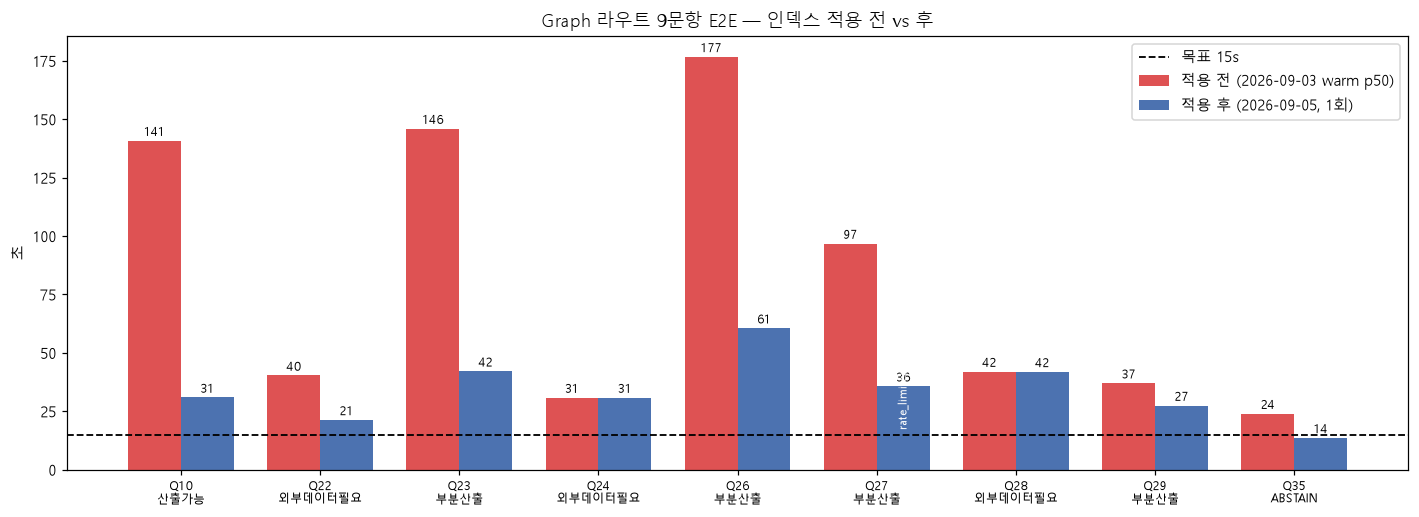

9문항 E2E 합계: 734s → 304s (59% 감소) · 15s 이내 문항: 1/9


In [ ]:
# 1) 문항별 E2E: 인덱스 적용 전(warm 3회 중앙값) vs 후(1회)
x = np.arange(len(GRAPH_Q)); w = 0.38
b = [before[q]["e2e"] for q in GRAPH_Q]; a = [after[q]["e2e_ms"] / 1000 for q in GRAPH_Q]
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(x - w/2, b, w, color="#d62728", alpha=0.8, label="적용 전 (2026-09-03 warm p50)")
ax.bar(x + w/2, a, w, color="#4c72b0", label="적용 후 (2026-09-05, 1회)")
ax.axhline(TARGET, color="black", ls="--", lw=1.2, label="목표 15s")
for i, (bv, av, q) in enumerate(zip(b, a, GRAPH_Q)):
    ax.text(i - w/2, bv + 2, f"{bv:.0f}", ha="center", fontsize=8); ax.text(i + w/2, av + 2, f"{av:.0f}", ha="center", fontsize=8)
    if after[q]["status"] != "ok": ax.text(i + w/2, av / 2, after[q]["status"], ha="center", fontsize=7, color="white", rotation=90)
ax.set_xticks(x); ax.set_xticklabels([f"{q}\n{golden.get(q, {}).get('data_status', '')}" for q in GRAPH_Q], fontsize=8)
ax.set_ylabel("초"); ax.set_title("Graph 라우트 9문항 E2E — 인덱스 적용 전 vs 후"); ax.legend(); plt.tight_layout(); plt.show()
tot_b, tot_a = sum(b), sum(a)
print(f"9문항 E2E 합계: {tot_b:.0f}s → {tot_a:.0f}s ({(1 - tot_a / tot_b) * 100:.0f}% 감소) · 15s 이내 문항: {sum(1 for v in a if v <= TARGET)}/9")

## 2. Graph 단계 시간 (노드·seed)

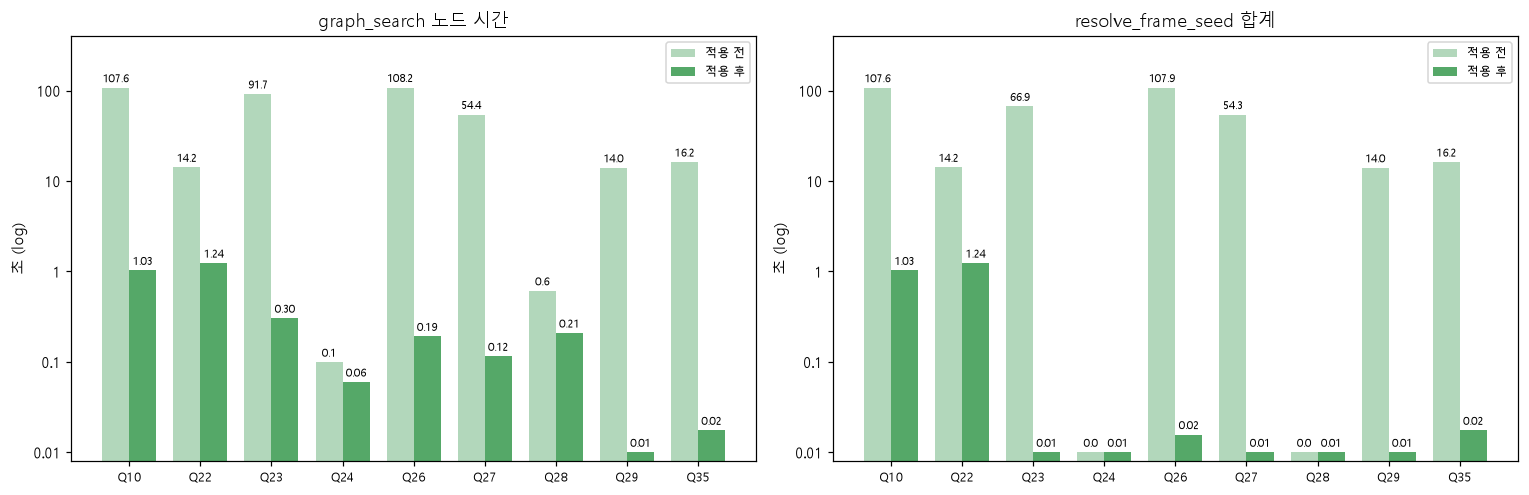

적용 전 seed는 클래스 전체 SPARQL 스캔(호출당 2.6~6.1s)이 role당 5~10회. 적용 후는 인덱스 조회 후 VALUES 로 좁힌 SPARQL 1회.


In [ ]:
# 2) graph 노드 시간과 seed 시간 — 로그 축 (0.1초와 100초를 한 그림에)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, key, title in [(axes[0], "graph", "graph_search 노드 시간"), (axes[1], "seed", "resolve_frame_seed 합계")]:
    bv = [max(before[q][key], 0.01) for q in GRAPH_Q]
    av = [max((node(after[q], "graph_search_node") if key == "graph" else sum(seeds(after[q]))), 0.01) for q in GRAPH_Q]
    ax.bar(x - w/2, bv, w, color="#55a868", alpha=0.45, label="적용 전")
    ax.bar(x + w/2, av, w, color="#55a868", label="적용 후")
    for i, (p, n_) in enumerate(zip(bv, av)):
        ax.text(i - w/2, p * 1.15, f"{p:.1f}", ha="center", fontsize=7); ax.text(i + w/2, n_ * 1.15, f"{n_:.2f}", ha="center", fontsize=7)
    ax.set_yscale("log"); ax.set_ylim(0.008, 400); ax.set_yticks([0.01, 0.1, 1, 10, 100]); ax.set_yticklabels(["0.01", "0.1", "1", "10", "100"]); ax.minorticks_off(); ax.set_xticks(x); ax.set_xticklabels(GRAPH_Q, fontsize=8); ax.set_ylabel("초 (log)")
    ax.set_title(title); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
print("적용 전 seed는 클래스 전체 SPARQL 스캔(호출당 2.6~6.1s)이 role당 5~10회. 적용 후는 인덱스 조회 후 VALUES 로 좁힌 SPARQL 1회.")

## 3. SPARQL 단건 지연 분포

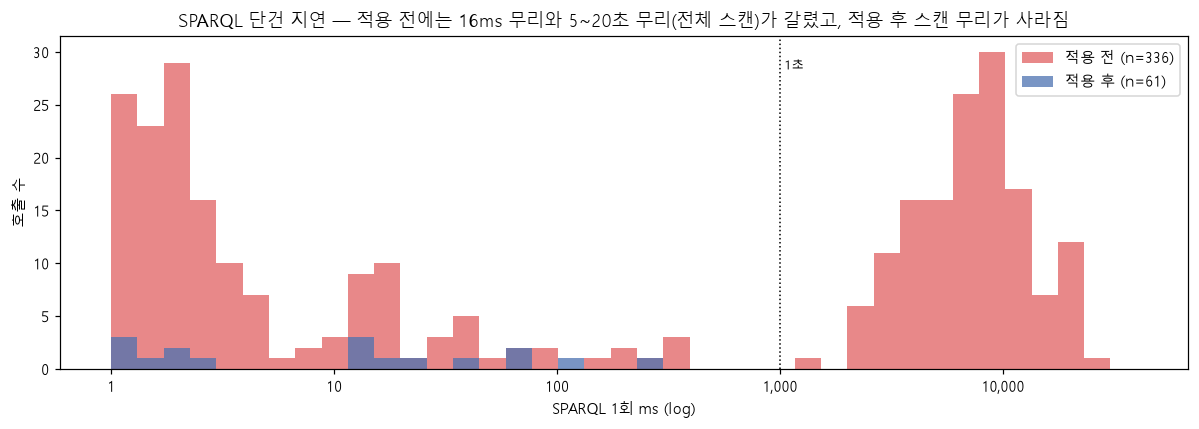

적용 전: p50 17ms / p95 14417ms / 1초 초과 143회
적용 후: p50 1ms / p95 64ms / 1초 초과 0회


In [4]:
# 3) SPARQL 단건 지연 분포 — Graph 9문항 기준
sb = [ms for t in before_all if t["status"] == "ok" for ms in sparqls(t)]
sa = [ms for t in after.values() for ms in sparqls(t)]
fig, ax = plt.subplots(figsize=(11, 4))
bins = np.logspace(0, 4.6, 40)
ax.hist(sb, bins=bins, alpha=0.55, color="#d62728", label=f"적용 전 (n={len(sb)})")
ax.hist(sa, bins=bins, alpha=0.75, color="#4c72b0", label=f"적용 후 (n={len(sa)})")
ax.set_xscale("log"); ax.set_xticks([1, 10, 100, 1000, 10000]); ax.set_xticklabels(["1", "10", "100", "1,000", "10,000"]); ax.minorticks_off(); ax.set_xlabel("SPARQL 1회 ms (log)"); ax.set_ylabel("호출 수")
ax.axvline(1000, color="black", ls=":", lw=1); ax.text(1050, ax.get_ylim()[1] * 0.9, "1초", fontsize=8)
ax.set_title("SPARQL 단건 지연 — 적용 전에는 16ms 무리와 5~20초 무리(전체 스캔)가 갈렸고, 적용 후 스캔 무리가 사라짐"); ax.legend()
plt.tight_layout(); plt.show()
def pct(v, q): v = sorted(v); return v[max(0, math.ceil(q * len(v)) - 1)] if v else 0
print(f"적용 전: p50 {pct(sb,.5):.0f}ms / p95 {pct(sb,.95):.0f}ms / 1초 초과 {sum(1 for v in sb if v > 1000)}회")
print(f"적용 후: p50 {pct(sa,.5):.0f}ms / p95 {pct(sa,.95):.0f}ms / 1초 초과 {sum(1 for v in sa if v > 1000)}회")

## 4. 남은 시간은 어디에 있는가

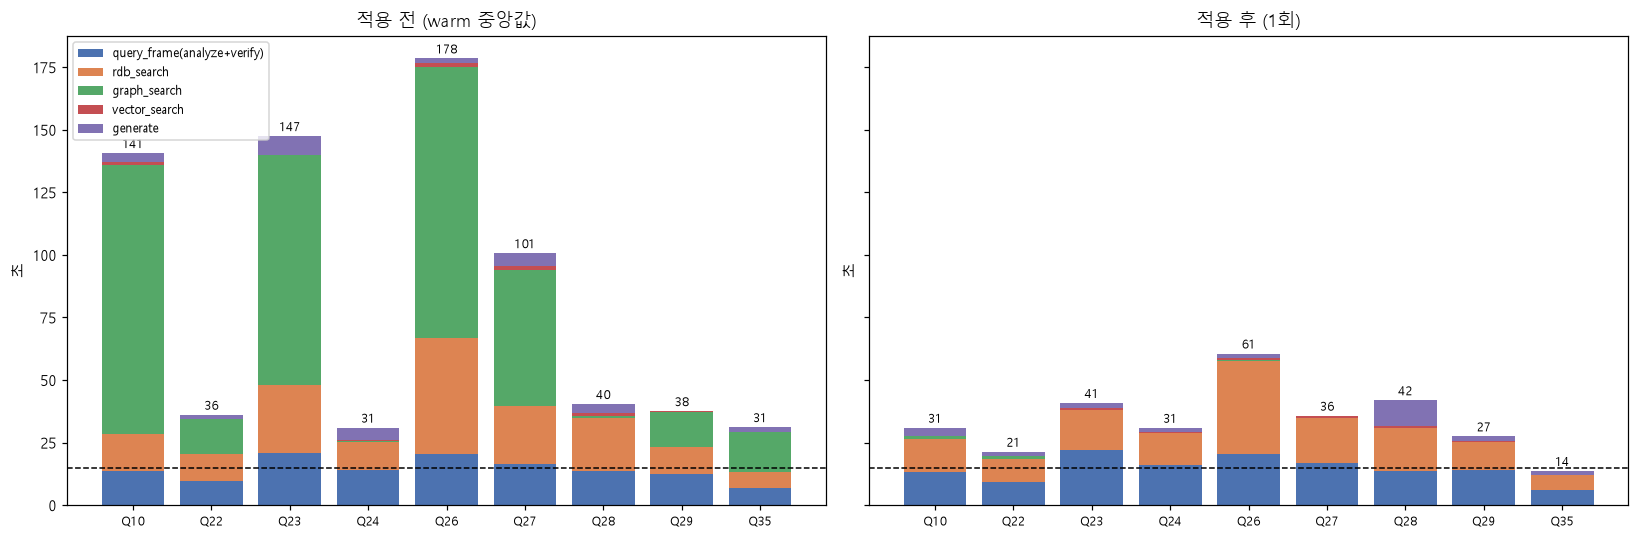

,frame,rdb,graph,vector,generate,E2E,LLM 호출
Q10,13.1,13.3,1.0,0.0,3.4,30.8942,6
Q22,9.2,9.2,1.2,0.0,1.7,21.2994,6
Q23,21.8,16.0,0.3,0.7,1.9,42.1283,8
Q24,15.9,12.8,0.1,0.5,1.6,30.8527,6
Q26,20.6,37.1,0.2,0.9,1.8,60.5538,13
Q27,16.7,18.0,0.1,0.7,0.2,35.7029,9
Q28,13.5,17.2,0.2,0.7,10.3,41.8742,7
Q29,13.9,11.3,0.0,0.7,1.7,27.4516,6
Q35,6.1,6.1,0.0,0.0,1.5,13.6070,5


적용 후 남은 시간은 query_frame(파랑)과 rdb_search(주황)가 거의 전부다. Graph(초록)는 보이지 않는 수준이다.


In [5]:
# 4) 적용 후 문항별 단계 누적 — 남은 시간이 어디에 있는가
stages = ["frame", "rdb", "graph", "vector", "generate"]
color = {"frame": "#4c72b0", "rdb": "#dd8452", "graph": "#55a868", "vector": "#c44e52", "generate": "#8172b3"}
label = {"frame": "query_frame(analyze+verify)", "rdb": "rdb_search", "graph": "graph_search", "vector": "vector_search", "generate": "generate"}
def stage_vals(t):
    return {"frame": node(t, "analyze_intent_node") + node(t, "verify_intent_node"), "rdb": node(t, "rdb_search_node"),
            "graph": node(t, "graph_search_node"), "vector": node(t, "vector_search_node"), "generate": node(t, "generate_answer_node")}
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, src, title in [(axes[0], {q: before[q] for q in GRAPH_Q}, "적용 전 (warm 중앙값)"), (axes[1], {q: stage_vals(after[q]) for q in GRAPH_Q}, "적용 후 (1회)")]:
    bottom = np.zeros(len(GRAPH_Q))
    for s in stages:
        vals = np.array([src[q][s] for q in GRAPH_Q]); ax.bar(GRAPH_Q, vals, bottom=bottom, color=color[s], label=label[s]); bottom += vals
    ax.axhline(TARGET, color="black", ls="--", lw=1)
    for i, tot in enumerate(bottom): ax.text(i, tot + 2, f"{tot:.0f}", ha="center", fontsize=8)
    ax.set_title(title); ax.set_ylabel("초"); ax.tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()
after_df = pd.DataFrame({q: stage_vals(after[q]) for q in GRAPH_Q}).T.round(1)
after_df["E2E"] = [after[q]["e2e_ms"] / 1000 for q in GRAPH_Q]; after_df["LLM 호출"] = [len(after[q]["timing"]["llm"]) for q in GRAPH_Q]
display(after_df)
print("적용 후 남은 시간은 query_frame(파랑)과 rdb_search(주황)가 거의 전부다. Graph(초록)는 보이지 않는 수준이다.")

## 5. Graph 단계 결과가 바뀌지 않았는가

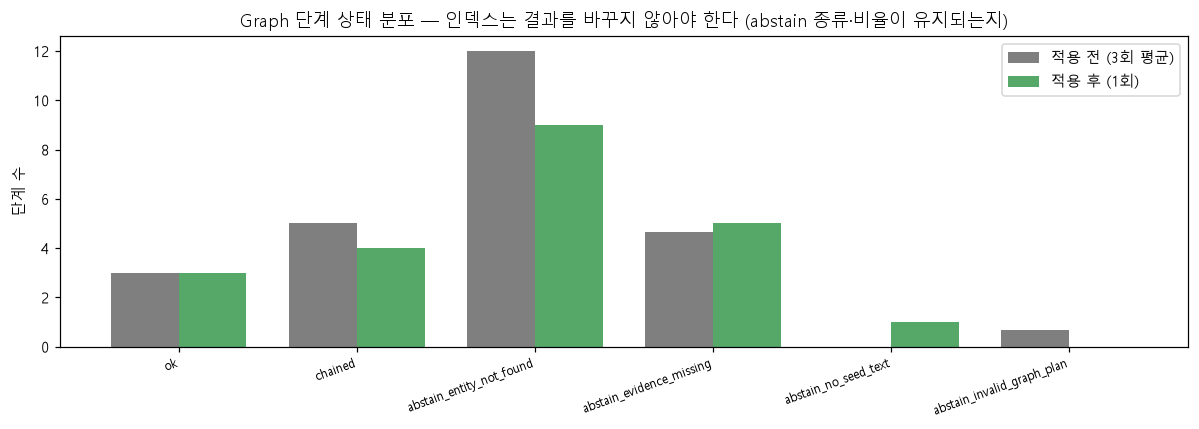

,적용 전 (warm 3회 합),적용 후 (1회),상태
ID,,,
Q10,"abstain_entity_not_found×6, chained×3","chained, abstain_entity_not_found, abstain_entity_not_found",ok
Q22,"abstain_entity_not_found×6, chained×1",abstain_entity_not_found,ok
Q23,"abstain_entity_not_found×9, ok×3","ok, abstain_no_seed_text",ok
Q24,"abstain_evidence_missing×3, chained×6","chained, chained, abstain_evidence_missing",ok
Q26,"abstain_entity_not_found×6, abstain_evidence_missing×7, chained×2","abstain_evidence_missing, abstain_entity_not_found, abstain_evidence_missing, abstain_entity_not_found, abstain_entity_not_found",ok
Q27,"abstain_entity_not_found×3, abstain_evidence_missing×4, abstain_invalid_graph_plan×2, chained×3","chained, abstain_entity_not_found, abstain_evidence_missing, abstain_evidence_missing",rate_limited
Q28,ok×6,"ok, ok",ok
Q29,abstain_entity_not_found×3,abstain_entity_not_found,ok
Q35,abstain_entity_not_found×3,abstain_entity_not_found,ok


적용 전후 abstain 유형이 같으면 인덱스가 결과를 바꾸지 않은 것이다. 단계 수 차이는 intent LLM 이 회차마다 다른 관계 계획을 내기 때문이다.


In [6]:
# 5) Graph 단계 상태 — 결과가 바뀌지 않았는지 (적용 전 warm 3회 합 vs 후 1회)
order = ["ok", "chained", "abstain_entity_not_found", "abstain_evidence_missing", "abstain_no_seed_text", "abstain_invalid_graph_plan", "abstain_entity_ambiguous"]
cb = Counter(); [cb.update(before[q]["statuses"]) for q in GRAPH_Q]
ca = Counter(s for q in GRAPH_Q for s in graph_statuses(after[q]))
keys = [k for k in order if cb[k] or ca[k]] + sorted((set(cb) | set(ca)) - set(order))
fig, ax = plt.subplots(figsize=(11, 4))
xx = np.arange(len(keys))
ax.bar(xx - w/2, [cb[k] / 3 for k in keys], w, color="#7f7f7f", label="적용 전 (3회 평균)")
ax.bar(xx + w/2, [ca[k] for k in keys], w, color="#55a868", label="적용 후 (1회)")
ax.set_xticks(xx); ax.set_xticklabels(keys, rotation=20, ha="right", fontsize=8); ax.set_ylabel("단계 수")
ax.set_title("Graph 단계 상태 분포 — 인덱스는 결과를 바꾸지 않아야 한다 (abstain 종류·비율이 유지되는지)"); ax.legend()
plt.tight_layout(); plt.show()

rows = []
for q in GRAPH_Q:
    rows.append({"ID": q, "적용 전 (warm 3회 합)": ", ".join(f"{k}×{v}" for k, v in sorted(before[q]["statuses"].items())),
                 "적용 후 (1회)": ", ".join(graph_statuses(after[q])) or "-", "상태": after[q]["status"]})
display(pd.DataFrame(rows).set_index("ID"))
print("적용 전후 abstain 유형이 같으면 인덱스가 결과를 바꾸지 않은 것이다. 단계 수 차이는 intent LLM 이 회차마다 다른 관계 계획을 내기 때문이다.")

## 6. 답변 전문 vs 골든 정답

In [7]:
# 6) 문항별 답변 vs 골든 정답 (전문)
rows = []
for q in GRAPH_Q:
    t = after[q]; g = golden.get(q, {}); a = t.get("answer") or {}
    ans = a.get("answer") if isinstance(a, dict) else a
    err = "; ".join(str(e.get("error", ""))[:120] for e in (t.get("errors") or []) if isinstance(e, dict))
    rows.append({"ID": q, "유형": f"{g.get('type','')}\n[{g.get('data_status','')}]", "상태 / E2E": f"{t['status']} / {t['e2e_ms']/1000:.1f}s",
                 "질문": g.get("question", ""), "파이프라인 답변 (적용 후)": (str(ans).strip() if ans else "(답변 없음)") + (f"\n⚠ {err}" if err else ""),
                 "골든 정답": g.get("golden_answer", "")})
ans_df = pd.DataFrame(rows).set_index("ID")
display(ans_df.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left", "vertical-align": "top", "font-size": "11px"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "11px")]}]))

,유형,상태 / E2E,질문,파이프라인 답변 (적용 후),골든 정답
ID,,,,,
Q10,단순조회_펀드클래스비교 [산출가능],ok / 30.9s,"우리반도체BIG2플러스의 C-P와 C-Pe 클래스가 동일한 모펀드의 클래스인지 확인하고, 클래스별 종목번호·판매 여부·순자산·수익률을 비교해줘. 동일 펀드 판정에 사용한 대표종목번호를 근거로 제시해줘.","{""상품명"":[""우리반도체BIG2플러스증권투자신탁(채권혼합)ClassC-Pe""], ""종목번호"":[""KR5118430059""], ""판매여부"":""판매중"", ""순자산"":""207882393292.0000"", ""수익률"":""57.90"", ""대표종목번호"":""031010005F29""}","동일 모펀드 여부: 예 (대표종목번호 031010005F29). 클래스 2종 — C-P: 종목번호 KR5118430058, 판매 판매중, 순자산 20억원, 1Y 57.61%, 보수 0.740% | C-Pe: 종목번호 KR5118430059, 판매 판매중, 순자산 2,079억원, 1Y 57.9%, 보수 0.540%"
Q22,관계검색_기업ETF편입 [외부데이터필요],ok / 21.3s,"캠브리콘이 실제 편입된 중국 반도체 ETF를 찾아줘. ETF→편입증권→기업 경로를 사용하고, ETF명·티커·편입비중·편입기준일·편입내역 문서명과 근거 문장을 제시해줘.",조건에 맞는 중국 반도체 ETF 정보가 부족하여 답변을 제공할 수 없습니다.,"주최측 데이터에는 4개 도메인 어디에도 보유종목(holdings) 컬럼이 없다. 주최측 안내상 섹터-상품·구성종목-상품 지식 구축은 참가자 자율이므로 **ABSTAIN이 아니라 외부 데이터로 채워야 하는 문항**이다. 캠브리콘/Cambricon은 4개 도메인 상품명·176테마 전수 검색 0건이므로 '상품명 매칭'으로는 답할 수 없고, 편입내역을 확보해야만 답이 나온다. 중국 관련 국내ETF 후보는 명칭 기준 56종."
Q23,시그널검색_기간테마연결 [부분산출],ok / 42.1s,"최근 6개월 동안 우주항공 테마와 연결된 이력이 있는 ETF를 정리해줘. 현재 편입 관계와 단순 뉴스 언급을 구분하고, ETF→편입기업→산업/테마→근거문서 경로, 사건일, 문서명과 인용 근거를 제시해줘.",(답변 없음),"LSEG themes로 '우주항공/방산' 태그 ETF 15종 식별 가능(예: KoAct 팔란티어밸류체인액티브, KODEX 방산TOP10레버리지, TIGER K방산&우주, TIME 글로벌우주테크&방산액티브, SOL K방산). 그러나 문항이 요구하는 '최근 6개월 연결 이력'은 시점 축이 필요한데 LSEG 메타에는 날짜 필드가 없다(themes·ter·replication·base_market·base_asset·hedge_type뿐)."
Q24,관계검색_자회사ETF위험 [외부데이터필요],ok / 30.9s,"에코프로의 자회사를 편입한 ETF를 찾고 그중 최신 AUM이 가장 큰 상품의 위험요인을 알려줘. 에코프로→자회사→편입종목→ETF 관계 근거, 편입비중·기준일, AUM 기준일과 위험요인 문서의 인용문을 제시해줘.",해당 질문에 대한 답변을 제공할 수 없습니다.,주최측 데이터에는 4개 도메인 어디에도 보유종목(holdings) 컬럼이 없다. 주최측 안내상 섹터-상품·구성종목-상품 지식 구축은 참가자 자율이므로 **ABSTAIN이 아니라 외부 데이터로 채워야 하는 문항**이다. 에코프로는 상품명 전수 검색상 채권에만 6건 존재하고 ETF/펀드 상품명에는 0건이다. '자회사' 관계도 주최측 데이터에 없다.
Q26,관계검색_기업멀티상품노출 [부분산출],ok / 60.6s,SK하이닉스가 발행한 매수 가능 채권과 SK하이닉스를 편입한 ETF·공모펀드를 연결해 알려줘. 발행사→채권과 기업→편입증권→상품 경로를 구분하고 등급·수익률·편입비중·AUM의 기준일과 근거를 제시해줘.,(답변 없음),"발행사→채권 경로는 산출 가능: '에스케이하이닉스(주)' 발행 채권 16종목 (구매가능 16종목). 등급 AA+ 16, (미평가) 1, 만기 20270214~20351110. 기업→편입증권→상품 경로는 편입내역 부재로 산출 불가."
Q27,관계검색_기업자회사멀티상품 [부분산출],rate_limited / 35.7s,"LG에너지솔루션 및 확인된 자회사가 발행한 채권과 이 기업들을 편입한 ETF를 찾아줘. 모자회사 관계의 공식 근거, 채권 신용등급·만기, ETF 편입비중을 제시하고 배터리산업 위험요인은 근거 문서별로 구분해줘.",(답변 없음) ⚠ SQL 생성 LLM 호출 실패: Error code: 429 - {'error': {'message': 'Too many requests: rate exceeded. Check response headers for,"'(주)엘지에너지솔루션' 발행 채권 12종목(상품명은 'LG에너지솔루션…'). LG에너지솔루션3-4(녹)(AA0, 만기 20310216); LG에너지솔루션5-3 (녹)(AA0, 만기 20310305); LG에너지솔루션4-2(AA0, 만기 20280214); LG에너지솔루션3-3(녹)(AA0, 만기 20290216); LG에너지솔루션2-3(녹)(AA0, 만기 20280629). 자회사 관계·ETF 편입비중·배터리 위험요인 문서는 원천에 없다."
Q28,관계검색_기업전략위험 [외부데이터필요],ok / 41.9s,"엔비디아를 편입한 국내 ETF와 해외 ETF 중 순자산이 큰 상품을 비교하고, 일반 지수형과 커버드콜형의 위험 차이를 설명해줘. 편입내역 기준일, 비중, AUM, 전략 원문 및 위험 설명의 문서 근거를 제시해줘.","엔비디아를 편입한 국내 ETF와 해외 ETF 중 순자산이 큰 상품으로는 다음과 같은 것들이 있습니다: ### 국내 ETF 1. **ACE 엔비디아채권혼합** - 순자산: 232,627,416,930 원 - 편입내역 기준일: 2026-02-13 - 비중 정보 및 AUM은 제공되지 않음. - 전략 원문은 투자설명서에 명시되어 있지 않음. - 위험 설명: 이 펀드는 고위험자산과 중위험자산에 분산 투자되며, 고위험자산에는 주식, 상품 등이 포함되고, 중위험자산에는 BBB급 채권 등이 포함됨. 투자위험등급은 보통 위험인 4등급으로 평가됨 (출처: 투자설명서, 기준일: 2026-02-13). 2. **KIWOOM 엔비디아미국30년국채혼합액티브** - 순자산 정보 및 기타 세부사항은 제공되지 않음. ### 해외 ETF 1. **Vanguard 500 Index Fund;ETF (VOO)** - 순자산: 997,351,790,000 원 - 편입내역 기준일, 비중, AUM 등의 정보는 제공되지 않음. - 전략 원문 및 위험 설명은 제공되지 않음. 2. **iShares Core S&P 500 ETF (IVV)** - 순자산: 889,429,740,000 원 - 편입내역 기준일, 비중, AUM 등의 정보는 제공되지 않음. - 전략 원문 및 위험 설명은 제공되지 않음. 3. **State Street SPDR S&P 500 ETF Trust (SPY)** - 순자산: 820,108,800,000 원 - 편입내역 기준일, 비중, AUM 등의 정보는 제공되지 않음. - 전략 원문 및 위험 설명은 제공되지 않음. 일반 지수형과 커버드콜형의 위험 차이에 대해서는 문서 근거가 부족하여 구체적인 설명을 제공할 수 없습니다.","주최측 데이터에는 4개 도메인 어디에도 보유종목(holdings) 컬럼이 없다. 주최측 안내상 섹터-상품·구성종목-상품 지식 구축은 참가자 자율이므로 **ABSTAIN이 아니라 외부 데이터로 채워야 하는 문항**이다. 상품명에 '엔비디아' 포함 국내ETF 6종은 찾을 수 있으나(1Q 엔비디아알파벳미국채혼합50, TIGER 엔비디아미국채커버드콜밸런스(합성), RISE 엔비디아고정테크100, ACE 엔비디아밸류체인액티브, KIWOOM 엔비디아미국30년국채혼합액티브(H)), 이는 '엔비디아를 편입한' 상품이 아니라 '이름에 엔비디아가 든' 상품이다. 혼동하면 오답. 커버드콜형은 상품명 '커버드콜' 토큰으로 62종 식별 가능."
Q29,관계검색_지수편입중복위험 [부분산출],ok / 27.5s,"VOO, IVV, SPY가

## 7. 판정

In [8]:
# 7) 한 줄 판정표 — 속도는 줄었는가, 답변은 맞는가
def verdict(q):
    t = after[q]; a = t.get("answer") or {}; ans = (a.get("answer") if isinstance(a, dict) else a) or ""
    if t["status"] != "ok": return "측정 불가(429)"
    if not str(ans).strip(): return "답변 없음(생성 실패)"
    if q in ("Q22", "Q24") and ("없" in ans or "제공할 수 없" in ans): return "부분: 부재는 맞게 말했으나 어떤 데이터가 필요한지 미설명"
    if q == "Q35": return "부분: '없다'만 답함 — 도메인 위반(ETF는 발행주체 아님) 사유 미설명"
    if q == "Q10": return "부분: C-Pe 한 클래스만 — C-P 누락, 대표종목번호는 정확"
    if q == "Q28": return "오답 위험: 이름에 '엔비디아' 든 상품을 '편입한' 상품으로 제시(과잉 추론), VOO·IVV·SPY 근거 없음"
    if q == "Q29": return "답변 본문 없음(머리말만)"
    return "검토 필요"
vt = pd.DataFrame([{"ID": q, "E2E 전→후": f"{before[q]['e2e']:.0f}s → {after[q]['e2e_ms']/1000:.0f}s", "graph 전→후": f"{before[q]['graph']:.1f}s → {node(after[q],'graph_search_node'):.1f}s",
                    "15s 이내": "O" if after[q]["e2e_ms"] <= 15000 else "X", "답변 판정(수동)": verdict(q)} for q in GRAPH_Q]).set_index("ID")
display(vt)
print("속도: Graph 단계는 9문항 모두 1.2초 이하. E2E는 Q35만 15초 이내 — 남은 병목은 RDB LLM SQL 체인과 Query Frame(Lane B·C).")
print("답변: 인덱스는 결과를 바꾸지 않으므로 답변 품질은 적용 전과 같은 문제(RDB SQL, ABSTAIN 사유 미전달, 생성 누락)를 그대로 보인다.")

,E2E 전→후,graph 전→후,15s 이내,답변 판정(수동)
ID,,,,
Q10,141s → 31s,107.6s → 1.0s,X,"부분: C-Pe 한 클래스만 — C-P 누락, 대표종목번호는 정확"
Q22,40s → 21s,14.2s → 1.2s,X,부분: 부재는 맞게 말했으나 어떤 데이터가 필요한지 미설명
Q23,146s → 42s,91.7s → 0.3s,X,답변 없음(생성 실패)
Q24,31s → 31s,0.1s → 0.1s,X,부분: 부재는 맞게 말했으나 어떤 데이터가 필요한지 미설명
Q26,177s → 61s,108.2s → 0.2s,X,답변 없음(생성 실패)
Q27,97s → 36s,54.4s → 0.1s,X,측정 불가(429)
Q28,42s → 42s,0.6s → 0.2s,X,"오답 위험: 이름에 '엔비디아' 든 상품을 '편입한' 상품으로 제시(과잉 추론), VOO·IVV·SPY 근거 없음"
Q29,37s → 27s,14.0s → 0.0s,X,답변 본문 없음(머리말만)
Q35,24s → 14s,16.2s → 0.0s,O,부분: '없다'만 답함 — 도메인 위반(ETF는 발행주체 아님) 사유 미설명


속도: Graph 단계는 9문항 모두 1.2초 이하. E2E는 Q35만 15초 이내 — 남은 병목은 RDB LLM SQL 체인과 Query Frame(Lane B·C).
답변: 인덱스는 결과를 바꾸지 않으므로 답변 품질은 적용 전과 같은 문제(RDB SQL, ABSTAIN 사유 미전달, 생성 누락)를 그대로 보인다.
